# LEGO VR — Practice Analysis Notebook

**Input:** synchronized participant files from `../data/merged/`  
**Output:** all-participant analysis tables and plots. No new preprocessing files are written.

### Pipeline overview
1. **Reuse preprocessing outputs** from the merged CSV files in `data/merged`
2. **Filter analysis rows** remove missing `model_name` and training models `TM`
3. **Exclude invalid trials/sessions** using the manual exclusion list
4. **Group gaze objects** collapse raw collider names into semantic `hit_obj_group` labels
5. **Classify gaze space** assign each sample to `model_area`, `resource_area`, `work_area`, or another broad area
6. **Annotate eye events** add consecutive `saccade_id`, `fixation_id`, `event_duration_ms`, and grouped `fixation_target`
7. **Annotate grab events** add left/right grab IDs from merged hand columns
8. **Stream all participants** one merged CSV at a time and keep only compact analysis tables
9. **Plot all-participant delay-behavior transitions** adapted from Melnik et al. (2018), then plot the previous grab-match checks

### Important upstream assumptions
The following steps are already handled by earlier notebooks and are **not recomputed here**:
- eye/body sampling-rate checks
- eye/body interpolation
- gaze angular velocity
- MAD thresholding
- fixation/saccade sample classification
- eye/body synchronization




# 1. Imports & Configuration



In [31]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")

DATA_DIR = Path("../data/merged")

REQUIRED_COLUMNS = [
    "participant_id",
    "condition_number",
    "trial_number",
    "raw_timestamp",
    "time_ms",
    "event_type",
    "angular_velocity",
    "mad_threshold",
    "hit_obj_name",
    "object_position_z",
    "LeftHand_grabbed_name",
    "RightHand_grabbed_name",
]

GROUP_COLS = ["participant_id", "condition_number", "trial_number"]
LEFT_GRABBED_COL = "LeftHand_grabbed_name"
RIGHT_GRABBED_COL = "RightHand_grabbed_name"


# 2. Participant Discovery & Schema Helpers

This notebook does not select or retain an example participant. It discovers every synchronized participant file here; the streaming pipeline later loads each file with only the required columns, validates it, extracts compact tables, and releases it before loading the next participant.



In [32]:
def list_available_participants(data_dir=DATA_DIR):
    return sorted(path.stem.replace("_synced", "") for path in data_dir.glob("*_synced.csv"))


def load_synced_participant(participant_id, data_dir=DATA_DIR, usecols=None):
    participant_id = str(participant_id).zfill(3)
    file_path = data_dir / f"{participant_id}_synced.csv"
    if not file_path.exists():
        available = ", ".join(list_available_participants(data_dir))
        raise FileNotFoundError(
            f"Missing synced file: {file_path}\n"
            f"Available participants: {available}"
        )

    df = pd.read_csv(file_path, usecols=usecols, low_memory=False)
    if "participant_id" in df.columns:
        df["participant_id"] = df["participant_id"].astype(str).str.zfill(3)
    return df, file_path


def validate_required_columns(df, required_columns=REQUIRED_COLUMNS):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise KeyError("Missing required column(s): " + ", ".join(missing))
    return True


ALL_PARTICIPANT_IDS = list_available_participants(DATA_DIR)
print(f"Discovered {len(ALL_PARTICIPANT_IDS)} synced participant files.")
print("Participants:", ", ".join(ALL_PARTICIPANT_IDS))


Discovered 51 synced participant files.
Participants: 001, 002, 003, 004, 005, 006, 007, 008, 009, 010, 011, 012, 013, 014, 015, 016, 017, 018, 019, 020, 021, 022, 023, 024, 025, 026, 027, 028, 029, 030, 031, 032, 033, 034, 035, 036, 037, 038, 039, 040, 041, 042, 043, 044, 045, 046, 047, 048, 049, 050, 051


# 3. Analysis Cleaning Function

The same row-level cleaning rule validated in `lego_practice_Azad.ipynb` is defined once and applied independently to every participant during streaming.



In [33]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filter rows for analysis only.

    Removes rows where model_name is missing or marks a training model (contains "TM").
    This does not redo any preprocessing from earlier notebooks.
    """
    out = df.copy()
    model = out["model_name"].astype("string")
    keep = model.notna() & ~model.str.contains("TM", case=False, na=False)
    return out.loc[keep].copy()


# 4. Exclude invalid trials



In [34]:
def exclude_participant_models(df, participant_id, model_name):
    """
    Remove model(s) belonging to one participant.

    model_name:
        str          -> remove one model
        list[str]    -> remove multiple models
        None         -> remove the entire participant
    """
    participant_values = pd.to_numeric(
        df["participant_id"], errors="coerce"
    )
    target_participant = pd.to_numeric(
        pd.Series([participant_id]), errors="coerce"
    ).iloc[0]

    participant_mask = participant_values.eq(target_participant)

    if model_name is None:
        remove_mask = participant_mask
    else:
        models = [model_name] if isinstance(model_name, str) else model_name
        models = [str(model).strip().casefold() for model in models]

        model_mask = (
            df["model_name"]
            .astype("string")
            .str.strip()
            .str.casefold()
            .isin(models)
        )

        remove_mask = participant_mask & model_mask

    return df.loc[~remove_mask].copy()


# None means that the participant's entire session is excluded.
EXCLUSIONS = [
    ("013", "C3M4A"),
    ("016", ["C1M2A", "C2M1F"]),
    ("018", "C2M6A"),
    ("019", "C3M1F"),
    ("025", "C3M2A"),
    ("033", ["C3M1F", "C3M2A"]),
    ("035", "C3M6A"),
    ("037", "C3M4A"),
    ("038", "C1M5F"),
    ("041", "C2M2A"),
    ("043", "C3M1F"),
    ("044", ["C1M3F", "C1M2A", "C3M1F"]),
    ("047", ["C3M4A", "C3M5F"]),
    ("050", "C3M1F"),
    ("004", None),
    ("036", None),
]


# 5. Quality-Control Summary



In [35]:
def make_qc_summary(df):
    agg = {
        "n_samples": ("time_ms", "size"),
    }

    if "bad_sample" in df.columns:
        agg["n_bad"] = ("bad_sample", "sum")
    if "is_interpolated" in df.columns:
        agg["n_interpolated"] = ("is_interpolated", "sum")

    for col in sorted(c for c in df.columns if c.startswith("bad_sample_")):
        agg[f"n_{col}"] = (col, "sum")
    for col in sorted(c for c in df.columns if c.startswith("is_interpolated_")):
        agg[f"n_{col}"] = (col, "sum")

    summary = (
        df.groupby(["condition_number", "trial_number"], dropna=False)
        .agg(**agg)
        .reset_index()
    )

    if "n_bad" in summary.columns:
        summary["pct_bad"] = 100 * summary["n_bad"] / summary["n_samples"]
    if "n_interpolated" in summary.columns:
        summary["pct_interpolated"] = 100 * summary["n_interpolated"] / summary["n_samples"]

    return summary


# 6. Object Grouping

Raw `hit_obj_name` values are collider-level labels. For example, a LEGO brick body and its stud colliders can have different names even though they belong to the same physical brick. This step creates `hit_obj_group`, a semantic gaze target used by later fixation-level analysis.

Examples:
- `brick_2x2_pink_temp_019` -> `temp_019`
- `stud_top_1_res_019` -> `res_019`
- `board_stud_top_045` -> `board`
- `Model_plate` -> `display_surface`



In [36]:
UI_BUTTONS = {
    "ContinueButton",
    "NextItemButton",
    "RotationButton",
    "ValidationButtonLeft",
    "ValidationButtonRight",
    "QuestionButton1",
    "QuestionButton2",
    "QuestionButton3",
    "QuestionButton4",
    "QuestionButton5",
    "QuestionButton6",
    "QuestionButton7",
    "ImageFixationCross",
}

WORKSPACE_OBJECTS = {"WorkBack", "WorkLeft", "WorkRight"}
ENVIRONMENT_OBJECTS = {"Lamp_Front_Left"}
DISPLAY_SURFACES = {"ModelFront", "ResourceFront", "Model_plate"}

# Large colored LEGO prefabs in the scene, not individual trial bricks.
LEGO_PREFABS = {
    "Lego_1x3_Green",
    "Lego_1x3_Pink",
    "Lego_1x3_Pink (1)",
    "Lego_2x2_Blue_Dis",
    "Lego_2x2_Orange",
    "Lego_3x2_Orange_Dis",
    "Lego_4x2_Blue",
    "Lego_4x2_Green",
    "Lego_4x2_Green (1)",
    "Lego_4x2_Orange",
    "Lego_4x2_Pink_Dis",
}


def get_object_group(name):
    """Group raw hit_obj_name collider labels into semantic gaze targets."""
    if pd.isna(name):
        return pd.NA

    name = str(name)

    if name in {"model_desk_base", "resource_desk_base", "work_desk_base"}:
        return name

    brick_match = re.search(r"_(res|temp|dis)_(\d+)", name, flags=re.IGNORECASE)
    if brick_match:
        status, brick_id = brick_match.groups()
        return f"{status.lower()}_{brick_id}"

    if re.match(r"board_stud_top_\d+", name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"

    if re.match(r"Wall_", name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"

    if name in UI_BUTTONS:
        return "ui"

    if name in WORKSPACE_OBJECTS:
        return "workspace"

    if name in DISPLAY_SURFACES:
        return "display_surface"

    if name in LEGO_PREFABS:
        return "lego_prefab"

    if name in ENVIRONMENT_OBJECTS:
        return "environment"

    return f"unknown_{name}"


# 7. Gaze Space

`hit_obj_group` describes object identity, while `gaze_space` describes the broader area or table. This keeps brick identity and spatial interpretation separate.

Values used here:
- `model_area`: template/model bricks, model plate/front, and model desk
- `resource_area`: resource-table bricks, resource front, and resource desk
- `work_area`: resource bricks after they move to the work side, board, workspace, and work desk
- `ui`: interface buttons and fixation cross
- `room`: walls, floor, ceiling, and room/environment objects
- `other`: discarded bricks and large LEGO prefab objects
- `unknown`: missing or unrecognized targets, including resource bricks without usable `object_position_z`

Resource bricks are separated with Rezvan's spatial rule: `object_position_z < -0.8` means the brick is still on the resource side; otherwise it is treated as being on the work side.



In [37]:
RESOURCE_AREA_Z_THRESHOLD = -0.8


def add_gaze_space(
    df,
    group_col="hit_obj_group",
    raw_col="hit_obj_name",
    z_col="object_position_z",
    space_col="gaze_space",
    resource_area_z_threshold=RESOURCE_AREA_Z_THRESHOLD,
):
    """Assign each gaze sample to a broad table/area label."""
    out = df.copy()

    group = out[group_col].astype("string")
    raw = out[raw_col].astype("string")
    z = pd.to_numeric(out[z_col], errors="coerce")

    out[space_col] = "other"

    missing_group = group.isna()
    unknown_group = group.str.startswith("unknown_", na=False)
    out.loc[missing_group | unknown_group, space_col] = "unknown"

    out.loc[
        group.str.startswith("temp_", na=False)
        | group.eq("model_desk_base")
        | raw.isin(["Model_plate", "ModelFront"]),
        space_col,
    ] = "model_area"

    resource_brick = group.str.startswith("res_", na=False)
    out.loc[resource_brick & z.lt(resource_area_z_threshold), space_col] = "resource_area"
    out.loc[resource_brick & z.ge(resource_area_z_threshold), space_col] = "work_area"
    out.loc[resource_brick & z.isna(), space_col] = "unknown"

    out.loc[group.eq("resource_desk_base") | raw.eq("ResourceFront"), space_col] = "resource_area"

    out.loc[
        group.isin(["board", "workspace", "work_desk_base"]),
        space_col,
    ] = "work_area"

    out.loc[group.eq("ui"), space_col] = "ui"
    out.loc[group.isin(["walls", "environment"]), space_col] = "room"
    out.loc[group.str.startswith("dis_", na=False) | group.eq("lego_prefab"), space_col] = "other"

    return out


# 8. Event Annotation



In [38]:
def add_saccade_fixation_ids(
    df,
    group_cols=GROUP_COLS,
    category_col="event_type",
    time_col="time_ms",
):
    """
    Add IDs for consecutive saccade and fixation runs.

    Output columns:
    - saccade_id
    - fixation_id
    - event_duration_ms
    """
    out = df.copy()
    out = out.sort_values(list(group_cols) + [time_col]).copy()

    out["saccade_id"] = pd.Series(index=out.index, dtype="Int64")
    out["fixation_id"] = pd.Series(index=out.index, dtype="Int64")
    out["event_duration_ms"] = np.nan

    saccade_counter = 0
    fixation_counter = 0

    for _, sub in out.groupby(list(group_cols), sort=False, dropna=False):
        sub = sub.sort_values(time_col)
        labels = sub[category_col].astype("string").tolist()
        times = pd.to_numeric(sub[time_col], errors="coerce").to_numpy(dtype=float)
        idx = sub.index.to_list()

        dt = np.diff(times)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

        run_start = 0
        for i in range(1, len(sub) + 1):
            if i == len(sub):
                run_ended = True
            else:
                curr_label = labels[i]
                start_label = labels[run_start]
                if pd.isna(curr_label) and pd.isna(start_label):
                    run_ended = False
                elif pd.isna(curr_label) or pd.isna(start_label):
                    run_ended = True
                else:
                    run_ended = curr_label != start_label

            if not run_ended:
                continue

            label = labels[run_start]
            run_idx = idx[run_start:i]
            n_rows = len(run_idx)

            if pd.notna(label) and n_rows > 0 and np.isfinite(median_dt):
                duration_ms = n_rows * median_dt
                out.loc[run_idx, "event_duration_ms"] = duration_ms

                if label == "saccade":
                    saccade_counter += 1
                    out.loc[run_idx, "saccade_id"] = saccade_counter
                elif label == "fixation":
                    fixation_counter += 1
                    out.loc[run_idx, "fixation_id"] = fixation_counter

            run_start = i

    return out.sort_index()


def add_fixation_target(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_group",
    target_col="fixation_target",
    group_cols=None,
):
    """
    Add a fixation-level target as the most frequent value of hit_col within each fixation.
    Ties are resolved by first appearance within the fixation.
    """
    out = df.copy()
    out[target_col] = pd.NA

    if group_cols is None:
        group_cols = [fixation_col]
    elif isinstance(group_cols, str):
        group_cols = [group_cols]
    else:
        group_cols = list(group_cols)

    valid = out[fixation_col].notna()

    def most_frequent_first_seen(s):
        s = s.dropna()
        if s.empty:
            return pd.NA
        counts = s.value_counts(sort=False)
        winners = set(counts[counts == counts.max()].index)
        for value in s:
            if value in winners:
                return value
        return pd.NA

    out.loc[valid, target_col] = (
        out.loc[valid]
        .groupby(group_cols, sort=False, dropna=False)[hit_col]
        .transform(most_frequent_first_seen)
    )

    return out


def add_grabbed_item_ids(
    df,
    left_col=LEFT_GRABBED_COL,
    right_col=RIGHT_GRABBED_COL,
    group_cols=GROUP_COLS,
    time_col="raw_timestamp",
):
    """Add consecutive grab IDs for left and right hands."""
    out = df.copy()
    sort_cols = [col for col in [*group_cols, time_col] if col in out.columns]
    group_cols = [col for col in group_cols if col in out.columns]

    out = out.sort_values(sort_cols).reset_index(drop=False)

    for hand, grabbed_col in [("lefthand", left_col), ("righthand", right_col)]:
        if grabbed_col not in out.columns:
            raise KeyError(f"Missing grabbed-object column: {grabbed_col}")

        grab_id_col = f"{hand}_grab_id"
        grabbed = out[grabbed_col].astype("string")
        is_grabbing = grabbed.notna() & grabbed.ne("") & grabbed.str.lower().ne("nan")

        previous = grabbed.groupby([out[col] for col in group_cols], dropna=False).shift()
        changed_object = grabbed.ne(previous)
        new_grab = is_grabbing & changed_object

        out[grab_id_col] = new_grab.cumsum()
        out.loc[~is_grabbing, grab_id_col] = pd.NA
        out[grab_id_col] = out[grab_id_col].astype("Int64")

    return out.sort_values("index").drop(columns="index").reset_index(drop=True)


## 8.1 Fixation-target dominance

The existing `fixation_target` column stores the most frequent grouped `hit_obj_group` within each fixation. This cell keeps that logic unchanged and adds two descriptive QC columns:

- `fixation_target_dominance_ratio`: the proportion of grouped samples in the fixation that match the selected `fixation_target`.
- `fixation_n_unique_targets`: the number of different grouped targets observed inside the fixation.

No threshold is applied here. The ratio is kept as a continuous measure so later analysis can decide how strict to be.



In [39]:
def add_fixation_target_dominance(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_group",
    target_col="fixation_target",
):
    """
    Add dominance information for the existing fixation_target.

    The function does not change fixation_target. It only reports how much
    of each fixation supports the already selected target.

    Output columns:
    - fixation_target_dominance_ratio: proportion of grouped samples equal to fixation_target
    - fixation_n_unique_targets: number of different hit_obj_group values in the fixation
    """
    out = df.copy()

    out["fixation_target_dominance_ratio"] = pd.NA
    out["fixation_n_unique_targets"] = pd.NA

    valid = out[fixation_col].notna()

    for _, group in out.loc[valid].groupby(fixation_col, sort=False):
        idx = group.index

        named_targets = group[hit_col].dropna()
        fixation_targets = group[target_col].dropna()

        if len(named_targets) == 0 or len(fixation_targets) == 0:
            dominance_ratio = pd.NA
            n_unique_targets = 0
        else:
            fixation_target = fixation_targets.iloc[0]
            dominance_ratio = (named_targets == fixation_target).sum() / len(named_targets)
            n_unique_targets = named_targets.nunique()

        out.loc[idx, "fixation_target_dominance_ratio"] = dominance_ratio
        out.loc[idx, "fixation_n_unique_targets"] = n_unique_targets

    return out


# 9. Build All-Participant Analysis Tables & Plots

All analysis data in this notebook are computed across the complete participant set. No example-participant dataframe is loaded or retained.

To avoid loading roughly 20 GB of merged CSV data at once, the code streams participant files one by one:

- load only columns needed for the match-rate analysis
- run the same cleaning/object-grouping/event-annotation logic for that participant
- create compact fixation/grab/match tables
- append only the compact tables
- delete the full participant dataframe before moving to the next file

All match-rate plots below use the same denominator: valid resource-side brick grabs, defined by a brick grab while the foot-area pair is one of `Resource/Resource`, `Resource/Middle`, or `Middle/Resource`.



In [40]:
# All-participant analysis helpers.
# This cell defines the streaming pipeline used by every plot below.

import gc

ALL_PARTICIPANT_IDS = list_available_participants(DATA_DIR)
ALL_PARTICIPANT_LIMIT = None  # set to a small number, e.g. 3, for quick testing

RESOURCE_STANCE_PAIRS = {("Resource", "Resource"), ("Resource", "Middle"), ("Middle", "Resource")}
N_PREVIOUS_MODEL_FIXATIONS = 5
ONE_HAND_TOP_N_TARGETS = 2
DUAL_GRAB_TOP4_TARGETS = 4
DUAL_GRAB_TOP5_TARGETS = 5

MELNIK_CONDITION_LABELS = {
    1: "No delay",
    2: "0.7 s delay",
    3: "2 s delay",
}
MELNIK_AREA_MAP = {
    "model_area": "M",
    "work_area": "W",
    "resource_area": "R",
}
MELNIK_TASK_SURFACE_GROUPS = {
    "model_desk_base",
    "resource_desk_base",
    "work_desk_base",
}
MELNIK_TASK_SURFACE_RAW_NAMES = {
    "Model_plate",
    "ModelFront",
    "ResourceFront",
}
MELNIK_SACCADE_TYPES = [
    "MM", "MW", "MR",
    "WM", "WW", "WR",
    "RM", "RW", "RR",
]

MODEL_FIXATION_MIN_DURATION_MS = 50.0
MODEL_FIXATION_MAX_GAP_PERIODS = 5.0

ALL_REQUIRED_COLUMNS = {
    "participant_id",
    "condition_number",
    "trial_number",
    "raw_timestamp",
    "time_ms",
    "event_type",
    "hit_obj_name",
    "object_position_z",
    "model_name",
    LEFT_GRABBED_COL,
    RIGHT_GRABBED_COL,
    "LeftFootArea",
    "RightFootArea",
}

ALL_OPTIONAL_COLUMNS = {
    "gaze_capture_time",
}

ALL_USECOLS = ALL_REQUIRED_COLUMNS | ALL_OPTIONAL_COLUMNS


def normalize_brick_id(value):
    """Extract and normalize brick IDs so 003, 03, and 3 compare as the same brick."""
    if pd.isna(value):
        return pd.NA

    match = re.search(r"(?:^|_)(?:temp|res|dis)_(\d+)$", str(value), flags=re.IGNORECASE)
    if match:
        return str(int(match.group(1)))
    return pd.NA


def first_non_missing(values):
    values = values.dropna()
    return values.iloc[0] if len(values) else pd.NA


def most_frequent_first_seen(values):
    values = values.dropna()
    if values.empty:
        return pd.NA

    counts = values.value_counts(sort=False)
    winners = set(counts[counts == counts.max()].index)
    for value in values:
        if value in winners:
            return value
    return pd.NA


def fixation_median_positive_step(values):
    """Return the nominal sampling period for one trial in milliseconds."""
    values = np.sort(pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float))
    steps = np.diff(values)
    steps = steps[np.isfinite(steps) & (steps > 0)]
    return float(np.median(steps)) if len(steps) else np.nan


def fixation_max_positive_gap(values):
    """Return the largest observed timestamp gap inside one fixation."""
    values = np.sort(pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float))
    steps = np.diff(values)
    steps = steps[np.isfinite(steps) & (steps > 0)]
    return float(steps.max()) if len(steps) else np.nan


def is_resource_stance(left_area, right_area):
    return (str(left_area), str(right_area)) in RESOURCE_STANCE_PAIRS


def same_trial_mask(table, row, group_cols=GROUP_COLS):
    mask = pd.Series(True, index=table.index)
    for col in group_cols:
        mask &= table[col].eq(row[col])
    return mask


def load_participant_minimal(participant_id, data_dir=DATA_DIR):
    """Load only the columns needed for all-participant match-rate plots."""
    participant_id = str(participant_id).zfill(3)
    file_path = data_dir / f"{participant_id}_synced.csv"

    header = pd.read_csv(file_path, nrows=0).columns
    missing = sorted(ALL_REQUIRED_COLUMNS - set(header))
    if missing:
        raise KeyError(f"{participant_id}: missing required columns: {missing}")

    usecols = [col for col in header if col in ALL_USECOLS]
    out = pd.read_csv(file_path, usecols=usecols, low_memory=False)
    out["participant_id"] = out["participant_id"].astype(str).str.zfill(3)
    return out


def prepare_participant_for_all_plots(participant_df):
    """Run the analysis-side preparation needed for all plots."""
    out = cleaning_function(participant_df)

    for participant_id, model_names in EXCLUSIONS:
        if out.empty:
            break
        out = exclude_participant_models(out, participant_id=participant_id, model_name=model_names)

    if out.empty:
        return out

    out["hit_obj_group"] = out["hit_obj_name"].apply(get_object_group)
    out = add_gaze_space(out)
    out = add_saccade_fixation_ids(out)
    out = add_fixation_target(out, group_cols=[*GROUP_COLS, "fixation_id"])
    out = add_grabbed_item_ids(out)
    return out


def make_fixation_events_all(df, group_cols=GROUP_COLS):
    """Create one row per fixation with model-area/template-brick information."""
    time_col = "gaze_capture_time" if "gaze_capture_time" in df.columns else "time_ms"
    fixation_rows = df[df["fixation_id"].notna()].copy()
    fixation_rows[time_col] = pd.to_numeric(fixation_rows[time_col], errors="coerce")
    fixation_rows["time_ms"] = pd.to_numeric(fixation_rows["time_ms"], errors="coerce")

    trial_sampling = (
        df.assign(time_ms_numeric=pd.to_numeric(df["time_ms"], errors="coerce"))
        .groupby(group_cols, dropna=False)["time_ms_numeric"]
        .apply(fixation_median_positive_step)
        .rename("sample_period_ms")
        .reset_index()
    )

    events = (
        fixation_rows.groupby([*group_cols, "fixation_id"], dropna=False)
        .agg(
            fixation_start_time=(time_col, "min"),
            fixation_end_time=(time_col, "max"),
            fixation_start_ms=("time_ms", "min"),
            fixation_end_ms=("time_ms", "max"),
            fixation_duration_ms=("event_duration_ms", first_non_missing),
            max_sample_gap_ms=("time_ms", fixation_max_positive_gap),
            fixation_target=("fixation_target", first_non_missing),
            fixation_gaze_space=("gaze_space", most_frequent_first_seen),
            fixation_hit_obj_group=("hit_obj_group", most_frequent_first_seen),
            fixation_hit_obj_name=("hit_obj_name", most_frequent_first_seen),
            n_fixation_samples=("time_ms", "size"),
        )
        .reset_index()
        .merge(trial_sampling, on=group_cols, how="left", validate="many_to_one")
        .sort_values([*group_cols, "fixation_start_time", "fixation_end_time"])
        .reset_index(drop=True)
    )
    events["audited_fixation_duration_ms"] = (
        events["fixation_end_ms"]
        - events["fixation_start_ms"]
        + events["sample_period_ms"]
    )
    events["has_continuous_sampling"] = (
        events["max_sample_gap_ms"].isna()
        | events["max_sample_gap_ms"].le(
            events["sample_period_ms"] * MODEL_FIXATION_MAX_GAP_PERIODS
        )
    )

    events["fixation_area_code"] = events["fixation_gaze_space"].map(MELNIK_AREA_MAP)
    events["is_mwr_fixation"] = events["fixation_area_code"].isin(["M", "W", "R"])
    events["is_task_surface_fixation"] = (
        events["fixation_hit_obj_group"].isin(MELNIK_TASK_SURFACE_GROUPS)
        | events["fixation_hit_obj_name"].isin(MELNIK_TASK_SURFACE_RAW_NAMES)
    )
    events["trial_fixation_position"] = events.groupby(group_cols, dropna=False).cumcount()
    events["fixation_brick_id"] = events["fixation_target"].apply(normalize_brick_id)
    events["is_model_brick_fixation"] = (
        events["fixation_gaze_space"].eq("model_area")
        & events["fixation_target"].astype("string").str.startswith("temp_", na=False)
        & events["fixation_brick_id"].notna()
    )
    return events


def make_grab_events_all(df, group_cols=GROUP_COLS):
    """Create one row per left/right brick grab, including resource-side stance."""
    time_col = "gaze_capture_time" if "gaze_capture_time" in df.columns else "time_ms"
    grab_tables = []

    hand_specs = [
        ("left", "lefthand_grab_id", LEFT_GRABBED_COL),
        ("right", "righthand_grab_id", RIGHT_GRABBED_COL),
    ]

    for hand, grab_id_col, grabbed_col in hand_specs:
        if grab_id_col not in df.columns or grabbed_col not in df.columns:
            continue

        grab_rows = df[df[grab_id_col].notna()].copy()
        if grab_rows.empty:
            continue

        grab_rows[time_col] = pd.to_numeric(grab_rows[time_col], errors="coerce")
        grab_rows["resource_stance_sample"] = [
            is_resource_stance(left, right)
            for left, right in zip(
                grab_rows["LeftFootArea"].astype("string"),
                grab_rows["RightFootArea"].astype("string"),
            )
        ]

        events = (
            grab_rows.groupby([*group_cols, grab_id_col], dropna=False)
            .agg(
                grab_start_time=(time_col, "min"),
                grab_end_time=(time_col, "max"),
                grab_start_ms=("time_ms", "min"),
                grab_end_ms=("time_ms", "max"),
                grabbed_object=(grabbed_col, most_frequent_first_seen),
                grab_left_foot_area=("LeftFootArea", most_frequent_first_seen),
                grab_right_foot_area=("RightFootArea", most_frequent_first_seen),
                grab_has_resource_stance=("resource_stance_sample", "any"),
                n_grab_samples=("time_ms", "size"),
            )
            .reset_index()
            .rename(columns={grab_id_col: "grab_id"})
        )

        events["grab_hand"] = hand
        events["grabbed_brick_id"] = events["grabbed_object"].apply(normalize_brick_id)
        grab_tables.append(events)

    if not grab_tables:
        return pd.DataFrame()

    grab_events = pd.concat(grab_tables, ignore_index=True)
    grab_events = grab_events[grab_events["grabbed_brick_id"].notna()].copy()
    grab_events["is_resource_side_grab"] = grab_events["grab_has_resource_stance"].astype(bool)

    return grab_events.sort_values([*group_cols, "grab_start_time", "grab_hand"]).reset_index(drop=True)


def get_previous_model_brick_fixations(fixation_events, grab_row, group_cols=GROUP_COLS):
    """Return previous model-area template-brick fixations, newest first."""
    same_trial = same_trial_mask(fixation_events, grab_row, group_cols=group_cols)
    before_grab = fixation_events["fixation_end_time"].le(grab_row["grab_start_time"])
    previous = fixation_events[
        same_trial
        & before_grab
        & fixation_events["is_model_brick_fixation"]
    ].copy()

    previous["time_since_fixation_ms"] = grab_row["grab_start_ms"] - previous["fixation_end_ms"]
    return previous.sort_values("fixation_end_time", ascending=False)


def previous_model_frame(fixation_events, grab_row, group_cols=GROUP_COLS):
    """Most recent continuous block of model-area template-brick fixations before one grab."""
    same_trial = same_trial_mask(fixation_events, grab_row, group_cols=group_cols)
    before_grab = fixation_events["fixation_end_time"].le(grab_row["grab_start_time"])
    trial_fixations = fixation_events[same_trial & before_grab].sort_values("fixation_end_time").reset_index(drop=True)

    model_positions = trial_fixations.index[trial_fixations["is_model_brick_fixation"]].tolist()
    if not model_positions:
        return trial_fixations.iloc[0:0].copy()

    end_pos = model_positions[-1]
    start_pos = end_pos
    while start_pos > 0 and bool(trial_fixations.loc[start_pos - 1, "is_model_brick_fixation"]):
        start_pos -= 1

    return trial_fixations.loc[start_pos:end_pos].copy()


def get_model_return_after_grab(fixation_events, grab_row, group_cols=GROUP_COLS):
    """First later model-area template-brick fixation after one grab."""
    same_trial = same_trial_mask(fixation_events, grab_row, group_cols=group_cols)
    after_grab = fixation_events["fixation_start_time"].gt(grab_row["grab_start_time"])
    candidates = fixation_events[same_trial & after_grab & fixation_events["is_model_brick_fixation"]]
    if candidates.empty:
        return None
    return candidates.sort_values("fixation_start_time").iloc[0]


def top_model_frame_targets_by_duration(model_frame, top_n):
    """Rank model-frame fixation targets by summed fixation duration, breaking ties by first appearance."""
    if model_frame.empty:
        return [], []

    work = model_frame[["fixation_target", "fixation_duration_ms"]].dropna(subset=["fixation_target"]).copy()
    if work.empty:
        return [], []

    work["fixation_target"] = work["fixation_target"].astype(str)
    work["fixation_duration_ms"] = pd.to_numeric(work["fixation_duration_ms"], errors="coerce").fillna(0)

    duration_sums = work.groupby("fixation_target", sort=False)["fixation_duration_ms"].sum()
    first_seen = {value: i for i, value in enumerate(dict.fromkeys(work["fixation_target"].tolist()))}
    ordered_targets = sorted(duration_sums.index, key=lambda value: (-duration_sums[value], first_seen[value]))[:top_n]
    ordered_ids = [normalize_brick_id(target) for target in ordered_targets]
    ordered_ids = [str(brick_id) for brick_id in ordered_ids if pd.notna(brick_id)]
    return ordered_targets, ordered_ids



## 9.1 Build All-Participant Analysis Tables

This cell creates compact all-participant tables for the analyses below:

- `all_participant_previous_fixation_matches`: exact-last and last-five previous model-brick fixation checks
- `all_participant_grab_decisions`: one-hand, dual-grab, and combined duration-ranked checks
- `all_participant_melnik_transition_trial_counts`: trial-level task-area transition counts
- `all_participant_trial_durations`: one duration row per valid trial
- `all_participant_model_area_fixation_trial_summary`: one model-area fixation-duration row per valid trial

The coverage report verifies that every valid resource-side brick grab is used exactly once: either as one one-hand decision or as part of one dual-grab pair.



In [41]:
def make_previous_fixation_matches_all(fixation_events, grab_events, group_cols=GROUP_COLS):
    """Check exact-last and last-five previous model-brick fixation matches."""
    resource_grabs = grab_events[
        grab_events["is_resource_side_grab"]
        & grab_events["grabbed_brick_id"].notna()
    ].copy()

    rows = []
    for _, grab in resource_grabs.iterrows():
        previous = get_previous_model_brick_fixations(fixation_events, grab, group_cols=group_cols)
        previous_to_check = previous.head(N_PREVIOUS_MODEL_FIXATIONS)
        previous_ids = previous_to_check["fixation_brick_id"].dropna().astype(str).tolist()
        previous_targets = previous_to_check["fixation_target"].dropna().astype(str).tolist()
        grabbed_id = str(grab["grabbed_brick_id"])

        rows.append({
            **{col: grab[col] for col in group_cols},
            "grab_hand": grab["grab_hand"],
            "grab_id": grab["grab_id"],
            "grab_start_ms": grab["grab_start_ms"],
            "grabbed_object": grab["grabbed_object"],
            "grabbed_brick_id": grabbed_id,
            "previous_model_fixation_targets": previous_targets,
            "previous_model_fixation_brick_ids": previous_ids,
            "n_previous_model_brick_fixations_checked": len(previous_to_check),
            "match_exact_last_fixation": grabbed_id in previous_ids[:1],
            "match_last_five_fixations": grabbed_id in previous_ids[:N_PREVIOUS_MODEL_FIXATIONS],
        })

    return pd.DataFrame(rows)


def grab_event_key(row, group_cols=GROUP_COLS):
    return tuple(row[col] for col in [*group_cols, "grab_hand", "grab_id"])


def make_grab_decisions_all(fixation_events, grab_events, group_cols=GROUP_COLS):
    """Classify each resource-side brick grab exactly once as one-hand or dual-grab."""
    resource_grabs = grab_events[
        grab_events["is_resource_side_grab"]
        & grab_events["grabbed_brick_id"].notna()
    ].copy()

    rows = []
    consumed = set()

    if resource_grabs.empty:
        return pd.DataFrame()

    ordered_grabs = resource_grabs.sort_values([*group_cols, "grab_start_time", "grab_hand"]).reset_index(drop=True)

    for _, trial_grabs in ordered_grabs.groupby(list(group_cols), sort=False, dropna=False):
        trial_grabs = trial_grabs.sort_values(["grab_start_time", "grab_hand"]).reset_index(drop=True)

        for pos, first_grab in trial_grabs.iterrows():
            first_key = grab_event_key(first_grab, group_cols=group_cols)
            if first_key in consumed:
                continue

            future_grabs = trial_grabs.iloc[pos + 1:]
            next_grab = future_grabs.iloc[0] if len(future_grabs) else None
            model_return = get_model_return_after_grab(fixation_events, first_grab, group_cols=group_cols)

            next_grab_before_model = (
                next_grab is not None
                and (model_return is None or next_grab["grab_start_time"] < model_return["fixation_start_time"])
            )
            next_grab_other_hand = (
                next_grab is not None
                and next_grab["grab_hand"] != first_grab["grab_hand"]
            )

            model_frame = previous_model_frame(fixation_events, first_grab, group_cols=group_cols)
            top_targets, top_ids = top_model_frame_targets_by_duration(model_frame, top_n=DUAL_GRAB_TOP5_TARGETS)

            if next_grab_before_model and next_grab_other_hand:
                second_grab = next_grab
                second_key = grab_event_key(second_grab, group_cols=group_cols)
                consumed.update({first_key, second_key})

                grabbed_ids = [
                    str(first_grab["grabbed_brick_id"]),
                    str(second_grab["grabbed_brick_id"]),
                ]

                rows.append({
                    **{col: first_grab[col] for col in group_cols},
                    "condition_type": "dual_grab",
                    "first_grab_hand": first_grab["grab_hand"],
                    "second_grab_hand": second_grab["grab_hand"],
                    "first_grab_start_ms": first_grab["grab_start_ms"],
                    "second_grab_start_ms": second_grab["grab_start_ms"],
                    "grabbed_brick_ids": grabbed_ids,
                    "ranked_model_frame_targets": top_targets,
                    "ranked_model_frame_brick_ids": top_ids,
                    "model_frame_n_fixations": len(model_frame),
                    "match_top1_model_frame_brick": pd.NA,
                    "match_top2_model_frame_bricks": pd.NA,
                    "match_dual_top4_model_frame_bricks": all(brick_id in top_ids[:DUAL_GRAB_TOP4_TARGETS] for brick_id in grabbed_ids),
                    "match_dual_top5_model_frame_bricks": all(brick_id in top_ids[:DUAL_GRAB_TOP5_TARGETS] for brick_id in grabbed_ids),
                    "match_combined_rule": all(brick_id in top_ids[:DUAL_GRAB_TOP5_TARGETS] for brick_id in grabbed_ids),
                })
                continue

            consumed.add(first_key)
            grabbed_id = str(first_grab["grabbed_brick_id"])

            rows.append({
                **{col: first_grab[col] for col in group_cols},
                "condition_type": "one_hand",
                "first_grab_hand": first_grab["grab_hand"],
                "second_grab_hand": pd.NA,
                "first_grab_start_ms": first_grab["grab_start_ms"],
                "second_grab_start_ms": pd.NA,
                "grabbed_brick_ids": [grabbed_id],
                "ranked_model_frame_targets": top_targets,
                "ranked_model_frame_brick_ids": top_ids,
                "model_frame_n_fixations": len(model_frame),
                "match_top1_model_frame_brick": grabbed_id in top_ids[:1],
                "match_top2_model_frame_bricks": grabbed_id in top_ids[:ONE_HAND_TOP_N_TARGETS],
                "match_dual_top4_model_frame_bricks": pd.NA,
                "match_dual_top5_model_frame_bricks": pd.NA,
                "match_combined_rule": grabbed_id in top_ids[:ONE_HAND_TOP_N_TARGETS],
            })

    return pd.DataFrame(rows)


def make_melnik_transition_events_all(
    fixation_events,
    group_cols=GROUP_COLS,
):
    """Connect M/W/R visits, bridging non-task fixations and flagging task surfaces."""
    if fixation_events.empty:
        return pd.DataFrame()

    current = fixation_events[
        fixation_events["condition_number"].isin(MELNIK_CONDITION_LABELS)
        & fixation_events["is_mwr_fixation"]
    ].copy()

    previous_cols = [
        "fixation_id",
        "fixation_start_time",
        "fixation_end_time",
        "fixation_start_ms",
        "fixation_end_ms",
        "fixation_duration_ms",
        "fixation_gaze_space",
        "fixation_area_code",
        "is_task_surface_fixation",
        "trial_fixation_position",
    ]

    for col in previous_cols:
        current[f"from_{col}"] = current.groupby(group_cols, dropna=False)[col].shift()

    transitions = current.rename(columns={
        "fixation_id": "to_fixation_id",
        "fixation_start_time": "to_fixation_start_time",
        "fixation_end_time": "to_fixation_end_time",
        "fixation_start_ms": "to_fixation_start_ms",
        "fixation_end_ms": "to_fixation_end_ms",
        "fixation_duration_ms": "to_fixation_duration_ms",
        "fixation_gaze_space": "to_gaze_space",
        "fixation_area_code": "to_area",
        "is_task_surface_fixation": "to_is_task_surface_fixation",
        "trial_fixation_position": "to_trial_fixation_position",
    }).rename(columns={
        "from_fixation_id": "from_fixation_id",
        "from_fixation_start_time": "from_fixation_start_time",
        "from_fixation_end_time": "from_fixation_end_time",
        "from_fixation_start_ms": "from_fixation_start_ms",
        "from_fixation_end_ms": "from_fixation_end_ms",
        "from_fixation_duration_ms": "from_fixation_duration_ms",
        "from_fixation_gaze_space": "from_gaze_space",
        "from_fixation_area_code": "from_area",
        "from_is_task_surface_fixation": "from_is_task_surface_fixation",
        "from_trial_fixation_position": "from_trial_fixation_position",
    }).copy()

    transitions = transitions[
        transitions["from_fixation_id"].notna()
        & transitions["to_fixation_id"].notna()
    ].copy()

    transitions["saccade_type"] = transitions["from_area"] + transitions["to_area"]

    transitions["n_intermediate_fixations"] = (
        transitions["to_trial_fixation_position"]
        - transitions["from_trial_fixation_position"]
        - 1
    ).astype(int)
    transitions["crosses_non_task_space"] = transitions["n_intermediate_fixations"].gt(0)
    transitions["is_within_area_transition"] = transitions["from_area"].eq(transitions["to_area"])
    transitions["is_valid_within_area_transition"] = (
        transitions["is_within_area_transition"]
        & ~transitions["from_is_task_surface_fixation"].eq(True)
        & ~transitions["to_is_task_surface_fixation"].eq(True)
    )
    transitions["include_in_figure3"] = (
        ~transitions["is_within_area_transition"]
        | transitions["is_valid_within_area_transition"]
    )
    transitions["time_between_fixations_ms"] = transitions["to_fixation_start_ms"] - transitions["from_fixation_end_ms"]
    transitions["condition_label"] = transitions["condition_number"].map(MELNIK_CONDITION_LABELS)

    keep_cols = [
        *group_cols,
        "condition_label",
        "saccade_type",
        "from_fixation_id",
        "to_fixation_id",
        "from_gaze_space",
        "to_gaze_space",
        "from_area",
        "to_area",
        "from_is_task_surface_fixation",
        "to_is_task_surface_fixation",
        "n_intermediate_fixations",
        "crosses_non_task_space",
        "is_valid_within_area_transition",
        "include_in_figure3",
        "from_fixation_end_ms",
        "to_fixation_start_ms",
        "time_between_fixations_ms",
        "from_fixation_duration_ms",
        "to_fixation_duration_ms",
    ]

    return transitions[keep_cols].reset_index(drop=True)


def make_melnik_transition_trial_counts_all(transition_events, fixation_events, group_cols=GROUP_COLS):
    """Count transition types per valid trial, keeping zero-count transition types."""
    if fixation_events.empty:
        return pd.DataFrame(columns=[*group_cols, "saccade_type", "n_saccades"])

    valid_fixations = fixation_events[
        fixation_events["condition_number"].isin(MELNIK_CONDITION_LABELS)
        & fixation_events["is_mwr_fixation"]
    ].copy()
    trial_keys = valid_fixations[group_cols].drop_duplicates().copy()
    type_grid = pd.DataFrame({"saccade_type": MELNIK_SACCADE_TYPES})
    full_grid = (
        trial_keys.assign(_key=1)
        .merge(type_grid.assign(_key=1), on="_key")
        .drop(columns="_key")
    )

    observed_counts = (
        transition_events.loc[transition_events["include_in_figure3"]]
        .groupby([*group_cols, "saccade_type"], dropna=False)
        .size()
        .rename("n_saccades")
        .reset_index()
    )

    return (
        full_grid.merge(observed_counts, on=[*group_cols, "saccade_type"], how="left")
        .assign(n_saccades=lambda x: x["n_saccades"].fillna(0).astype(int))
    )


def make_trial_durations_all(df, transition_trial_counts, group_cols=GROUP_COLS):
    """Return one duration row for every valid trial represented in the transition table."""
    if transition_trial_counts.empty:
        return pd.DataFrame(columns=[*group_cols, "trial_start_ms", "trial_end_ms", "n_samples", "trial_duration_s"])

    trial_keys = transition_trial_counts[group_cols].drop_duplicates()
    valid_rows = df[df["condition_number"].isin(MELNIK_CONDITION_LABELS)].copy()
    valid_rows["time_ms"] = pd.to_numeric(valid_rows["time_ms"], errors="coerce")

    durations = (
        valid_rows.dropna(subset=["time_ms"])
        .groupby(group_cols, dropna=False)
        .agg(
            trial_start_ms=("time_ms", "min"),
            trial_end_ms=("time_ms", "max"),
            n_samples=("time_ms", "size"),
        )
        .reset_index()
    )
    durations["trial_duration_s"] = (durations["trial_end_ms"] - durations["trial_start_ms"]) / 1000
    return trial_keys.merge(durations, on=group_cols, how="inner")


def make_model_area_fixation_trial_summary_all(fixation_events, group_cols=GROUP_COLS):
    """Retain one compact valid model-area fixation-duration row per trial."""
    model_fixations = fixation_events[
        fixation_events["condition_number"].isin(MELNIK_CONDITION_LABELS)
        & fixation_events["fixation_gaze_space"].eq("model_area")
        & fixation_events["audited_fixation_duration_ms"].ge(
            MODEL_FIXATION_MIN_DURATION_MS
        )
        & fixation_events["has_continuous_sampling"]
    ].copy()
    model_fixations["audited_fixation_duration_ms"] = pd.to_numeric(
        model_fixations["audited_fixation_duration_ms"], errors="coerce"
    )
    model_fixations = model_fixations[
        model_fixations["audited_fixation_duration_ms"].notna()
    ]

    if model_fixations.empty:
        return pd.DataFrame(columns=[
            *group_cols,
            "n_model_area_fixations",
            "mean_fixation_duration_ms",
            "median_fixation_duration_ms",
            "total_model_area_fixation_ms",
        ])

    return (
        model_fixations.groupby(group_cols, dropna=False)
        .agg(
            n_model_area_fixations=("fixation_id", "size"),
            mean_fixation_duration_ms=("audited_fixation_duration_ms", "mean"),
            median_fixation_duration_ms=("audited_fixation_duration_ms", "median"),
            total_model_area_fixation_ms=("audited_fixation_duration_ms", "sum"),
        )
        .reset_index()
    )


def process_participant_for_all_plots(participant_id):
    raw = load_participant_minimal(participant_id)
    raw_rows = len(raw)

    participant_df = prepare_participant_for_all_plots(raw)
    analysis_rows = len(participant_df)
    del raw

    participant_id = str(participant_id).zfill(3)

    if participant_df.empty:
        report = {
            "participant_id": participant_id,
            "raw_rows": raw_rows,
            "analysis_rows": analysis_rows,
            "n_resource_brick_grabs": 0,
            "n_previous_match_rows": 0,
            "n_one_hand_decisions": 0,
            "n_dual_grab_pairs": 0,
            "n_grabs_covered": 0,
            "n_melnik_transition_rows": 0,
            "n_melnik_transition_trials": 0,
            "n_trial_duration_rows": 0,
            "n_model_fixation_trial_rows": 0,
            "coverage_ok": True,
            "status": "no analysis rows after cleaning/exclusions",
        }
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), report

    fixation_events = make_fixation_events_all(participant_df)
    grab_events = make_grab_events_all(participant_df)

    resource_grabs = grab_events[
        grab_events["is_resource_side_grab"]
        & grab_events["grabbed_brick_id"].notna()
    ].copy()

    previous_matches = make_previous_fixation_matches_all(fixation_events, grab_events)
    grab_decisions = make_grab_decisions_all(fixation_events, grab_events)
    melnik_transition_events = make_melnik_transition_events_all(fixation_events)
    melnik_transition_counts = make_melnik_transition_trial_counts_all(
        melnik_transition_events,
        fixation_events,
    )
    trial_durations = make_trial_durations_all(participant_df, melnik_transition_counts)
    model_fixation_trial_summary = make_model_area_fixation_trial_summary_all(fixation_events)

    n_one_hand = int(grab_decisions["condition_type"].eq("one_hand").sum()) if len(grab_decisions) else 0
    n_dual = int(grab_decisions["condition_type"].eq("dual_grab").sum()) if len(grab_decisions) else 0
    n_resource_grabs = len(resource_grabs)
    n_grabs_covered = n_one_hand + 2 * n_dual

    report = {
        "participant_id": participant_id,
        "raw_rows": raw_rows,
        "analysis_rows": analysis_rows,
        "n_resource_brick_grabs": n_resource_grabs,
        "n_previous_match_rows": len(previous_matches),
        "n_one_hand_decisions": n_one_hand,
        "n_dual_grab_pairs": n_dual,
        "n_grabs_covered": n_grabs_covered,
        "n_melnik_transition_rows": len(melnik_transition_events),
        "n_melnik_transition_trials": melnik_transition_counts[GROUP_COLS].drop_duplicates().shape[0],
        "n_trial_duration_rows": len(trial_durations),
        "n_model_fixation_trial_rows": len(model_fixation_trial_summary),
        "coverage_ok": n_resource_grabs == n_grabs_covered == len(previous_matches),
        "status": "ok",
    }

    del participant_df, fixation_events, grab_events, resource_grabs, melnik_transition_events
    gc.collect()

    return previous_matches, grab_decisions, melnik_transition_counts, trial_durations, model_fixation_trial_summary, report


def make_all_participant_plot_tables(participant_ids=None, limit=ALL_PARTICIPANT_LIMIT):
    participant_ids = list(ALL_PARTICIPANT_IDS if participant_ids is None else participant_ids)
    if limit is not None:
        participant_ids = participant_ids[:limit]

    previous_tables = []
    decision_tables = []
    melnik_transition_tables = []
    trial_duration_tables = []
    model_fixation_trial_tables = []
    report_rows = []

    for i, participant_id in enumerate(participant_ids, start=1):
        participant_id = str(participant_id).zfill(3)
        print(f"[{i:02d}/{len(participant_ids):02d}] Processing participant {participant_id}", flush=True)

        try:
            previous_matches, grab_decisions, melnik_transition_counts, trial_durations, model_fixation_trial_summary, report = process_participant_for_all_plots(participant_id)
        except Exception as exc:
            previous_matches = pd.DataFrame()
            grab_decisions = pd.DataFrame()
            melnik_transition_counts = pd.DataFrame()
            trial_durations = pd.DataFrame()
            model_fixation_trial_summary = pd.DataFrame()
            report = {
                "participant_id": participant_id,
                "raw_rows": pd.NA,
                "analysis_rows": pd.NA,
                "n_resource_brick_grabs": pd.NA,
                "n_previous_match_rows": pd.NA,
                "n_one_hand_decisions": pd.NA,
                "n_dual_grab_pairs": pd.NA,
                "n_grabs_covered": pd.NA,
                "n_melnik_transition_rows": pd.NA,
                "n_melnik_transition_trials": pd.NA,
                "n_trial_duration_rows": pd.NA,
                "n_model_fixation_trial_rows": pd.NA,
                "coverage_ok": False,
                "status": f"ERROR: {exc}",
            }
            print(f"  ERROR: {exc}", flush=True)

        if not previous_matches.empty:
            previous_tables.append(previous_matches)
        if not grab_decisions.empty:
            decision_tables.append(grab_decisions)
        if not melnik_transition_counts.empty:
            melnik_transition_tables.append(melnik_transition_counts)
        if not trial_durations.empty:
            trial_duration_tables.append(trial_durations)
        if not model_fixation_trial_summary.empty:
            model_fixation_trial_tables.append(model_fixation_trial_summary)
        report_rows.append(report)

        del previous_matches, grab_decisions, melnik_transition_counts, trial_durations, model_fixation_trial_summary
        gc.collect()

    all_previous = pd.concat(previous_tables, ignore_index=True) if previous_tables else pd.DataFrame()
    all_decisions = pd.concat(decision_tables, ignore_index=True) if decision_tables else pd.DataFrame()
    all_melnik_transitions = pd.concat(melnik_transition_tables, ignore_index=True) if melnik_transition_tables else pd.DataFrame()
    all_trial_durations = pd.concat(trial_duration_tables, ignore_index=True) if trial_duration_tables else pd.DataFrame()
    all_model_fixation_trials = pd.concat(model_fixation_trial_tables, ignore_index=True) if model_fixation_trial_tables else pd.DataFrame()
    coverage_report = pd.DataFrame(report_rows)

    return all_previous, all_decisions, all_melnik_transitions, all_trial_durations, all_model_fixation_trials, coverage_report


(
    all_participant_previous_fixation_matches,
    all_participant_grab_decisions,
    all_participant_melnik_transition_trial_counts,
    all_participant_trial_durations,
    all_participant_model_area_fixation_trial_summary,
    all_participant_coverage_report,
) = make_all_participant_plot_tables()

print("\nCoverage report")
display(all_participant_coverage_report)

if not all_participant_coverage_report["coverage_ok"].fillna(False).all():
    print("Some participants failed coverage checks. Inspect the report before interpreting plots.")
else:
    print("Coverage OK: every valid resource-side brick grab is used exactly once.")

print(f"Previous-fixation match rows: {len(all_participant_previous_fixation_matches):,}")
print(f"One-hand/dual decision rows: {len(all_participant_grab_decisions):,}")
print(f"Melnik transition trial rows: {len(all_participant_melnik_transition_trial_counts):,}")
print(f"Trial-duration rows: {len(all_participant_trial_durations):,}")
print(f"Model-area fixation trial rows: {len(all_participant_model_area_fixation_trial_summary):,}")



[01/51] Processing participant 001
[02/51] Processing participant 002
[03/51] Processing participant 003
[04/51] Processing participant 004
[05/51] Processing participant 005
[06/51] Processing participant 006
[07/51] Processing participant 007
[08/51] Processing participant 008
[09/51] Processing participant 009
[10/51] Processing participant 010
[11/51] Processing participant 011
[12/51] Processing participant 012
[13/51] Processing participant 013
[14/51] Processing participant 014
[15/51] Processing participant 015
[16/51] Processing participant 016
[17/51] Processing participant 017
[18/51] Processing participant 018
[19/51] Processing participant 019
[20/51] Processing participant 020
[21/51] Processing participant 021
[22/51] Processing participant 022
[23/51] Processing participant 023
[24/51] Processing participant 024
[25/51] Processing participant 025
[26/51] Processing participant 026
[27/51] Processing participant 027
[28/51] Processing participant 028
[29/51] Processing p

,participant_id,raw_rows,analysis_rows,n_resource_brick_grabs,n_previous_match_rows,n_one_hand_decisions,n_dual_grab_pairs,n_grabs_covered,n_melnik_transition_rows,n_melnik_transition_trials,n_trial_duration_rows,n_model_fixation_trial_rows,coverage_ok,status
0,001,646964,354382,74,74,34,20,74,8044,18,18,18,True,ok
1,002,569983,275225,64,64,38,13,64,7153,18,18,18,True,ok
2,003,456127,175358,56,56,26,15,56,5424,18,18,18,True,ok
3,004,180076,0,0,0,0,0,0,0,0,0,0,True,no analysis rows after cleaning/exclusions
4,005,703259,348889,83,83,49,17,83,9251,18,18,18,True,ok
5,006,663196,352742,42,42,30,6,42,7840,18,18,18,True,ok
6,007,570584,277467,61,61,27,17,61,8436,18,18,18,True,ok
7,008,423981,210712,52,52,30,11,52,3664,18,18,18,True,ok
8,009,469539,223389,64,64,30,17,64,6806,18,18,18,True,ok
9,010,593523,342813,63,63,33,15,63,8508,18,18,18,True,ok


Coverage OK: every valid resource-side brick grab is used exactly once.
Previous-fixation match rows: 2,879
One-hand/dual decision rows: 2,276
Melnik transition trial rows: 7,767
Trial-duration rows: 863
Model-area fixation trial rows: 863


## 9.2 Delay Behavior: Melnik Figure 3-Style Gaze-Space Transitions Across Participants

These plots adapt Melnik et al.'s Figure 3 to our all-participant LEGO VR data. Participant files are processed one at a time, and only compact trial-level transition counts are retained after cleaning and manual exclusions.

Between-area transitions bridge intervening `room`, `other`, `ui`, and `unknown` fixations. Thus, `work_area -> room -> resource_area` is counted as `WR`. Within-area transitions use the stricter content-to-content rule validated in the single-participant notebook: transitions with a desk, plate, or front-surface fixation at either endpoint are excluded. Therefore, `work content -> room -> work content` counts as `WW`, while `work content -> work_desk_base -> work content` does not.

The value in each bar is the mean number of included fixation-to-fixation transitions per valid trial. Error bars show SEM across valid trials. The charts are split because the between-area and within-area counts use different scales.




All-participant Melnik-style transition summary
Valid participant files processed: 49
Valid trials summarized: 863
Mean transitions per valid trial:


condition_label,0.7 s delay,2 s delay,No delay
saccade_type,,,
MM,91.16,75.91,68.39
MW,4.68,2.72,7.51
MR,2.51,1.80,3.89
WM,5.98,3.49,9.36
WW,145.44,137.50,142.64
WR,1.89,2.45,1.13
RM,0.47,0.19,1.57
RW,3.94,4.07,3.46
RR,44.93,43.08,47.37


SEM transitions per valid trial:


condition_label,0.7 s delay,2 s delay,No delay
saccade_type,,,
MM,6.17,4.61,4.21
MW,0.30,0.17,0.44
MR,0.09,0.07,0.14
WM,0.33,0.19,0.48
WW,7.90,7.33,8.21
WR,0.09,0.11,0.08
RM,0.05,0.03,0.09
RW,0.11,0.12,0.12
RR,1.87,1.95,1.92


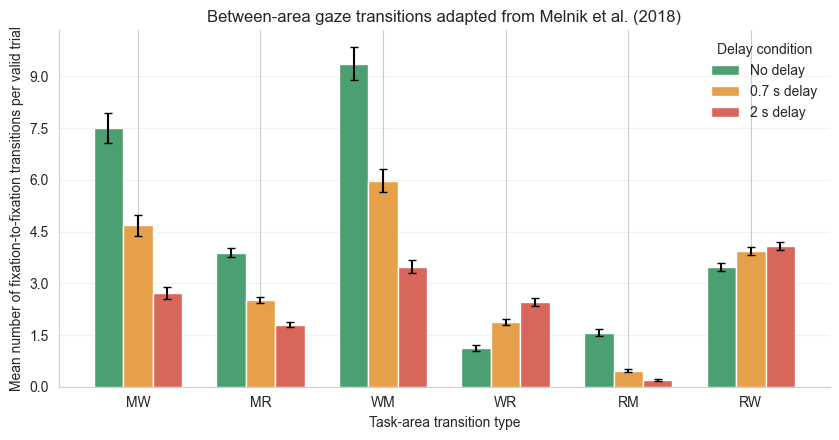

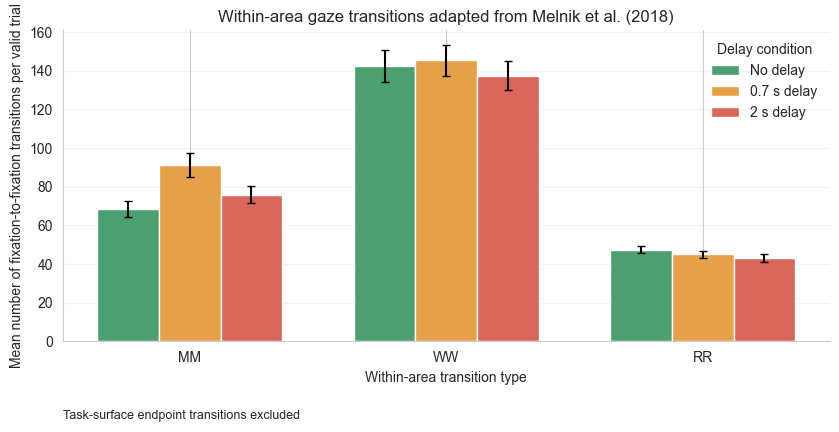

<Axes: title={'center': 'Within-area gaze transitions adapted from Melnik et al. (2018)'}, xlabel='Within-area transition type', ylabel='Mean number of fixation-to-fixation transitions per valid trial'>

In [42]:
def melnik_sem(values):
    values = pd.to_numeric(values, errors="coerce").dropna()
    if len(values) <= 1:
        return 0.0
    return values.std(ddof=1) / np.sqrt(len(values))


def make_melnik_transition_summary_all(transition_trial_counts):
    """Summarize all-participant transition counts as mean +/- SEM per valid trial."""
    if transition_trial_counts.empty:
        return pd.DataFrame(columns=["condition_number", "saccade_type", "mean_saccades", "sem_saccades", "n_trials"])

    summary = (
        transition_trial_counts.groupby(["condition_number", "saccade_type"], dropna=False)
        .agg(
            mean_saccades=("n_saccades", "mean"),
            sem_saccades=("n_saccades", melnik_sem),
            n_trials=("n_saccades", "size"),
        )
        .reset_index()
    )
    summary["condition_label"] = summary["condition_number"].map(MELNIK_CONDITION_LABELS)
    return summary


def plot_melnik_transition_group_all(summary, transition_types, title, xlabel):
    if summary.empty:
        print("No transition summary available for plotting.")
        return None

    condition_numbers = [cond for cond in MELNIK_CONDITION_LABELS if cond in set(summary["condition_number"])]
    x = np.arange(len(transition_types))
    bar_width = 0.24 if len(condition_numbers) == 3 else 0.32
    colors = ["#4C9F70", "#E6A04A", "#D8665B"]

    fig, ax = plt.subplots(figsize=(8.5, 4.5))

    for i, cond in enumerate(condition_numbers):
        cond_summary = (
            summary[summary["condition_number"].eq(cond)]
            .set_index("saccade_type")
            .reindex(transition_types)
        )
        means = cond_summary["mean_saccades"].fillna(0).to_numpy(dtype=float)
        sems = cond_summary["sem_saccades"].fillna(0).to_numpy(dtype=float)
        offset = (i - (len(condition_numbers) - 1) / 2) * bar_width

        ax.bar(
            x + offset,
            means,
            width=bar_width,
            yerr=sems,
            capsize=3,
            color=colors[i % len(colors)],
            edgecolor="white",
            linewidth=1.0,
            label=MELNIK_CONDITION_LABELS[cond],
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mean number of fixation-to-fixation transitions per valid trial")
    ax.set_xticks(x)
    ax.set_xticklabels(transition_types)
    ax.yaxis.set_major_locator(MaxNLocator(integer=False))
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(title="Delay condition", frameon=False)

    if transition_types == ["MM", "WW", "RR"]:
        ax.text(
            0.0,
            -0.22,
            "Task-surface endpoint transitions excluded",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
    return ax


all_participant_melnik_transition_summary = make_melnik_transition_summary_all(
    all_participant_melnik_transition_trial_counts
)

all_participant_melnik_mean_table = (
    all_participant_melnik_transition_summary.pivot(
        index="saccade_type",
        columns="condition_label",
        values="mean_saccades",
    )
    .reindex(MELNIK_SACCADE_TYPES)
)

all_participant_melnik_sem_table = (
    all_participant_melnik_transition_summary.pivot(
        index="saccade_type",
        columns="condition_label",
        values="sem_saccades",
    )
    .reindex(MELNIK_SACCADE_TYPES)
)

print("All-participant Melnik-style transition summary")
print(f"Valid participant files processed: {all_participant_coverage_report['status'].eq('ok').sum():,}")
print(f"Valid trials summarized: {all_participant_melnik_transition_trial_counts[GROUP_COLS].drop_duplicates().shape[0]:,}")
print("Mean transitions per valid trial:")
display(all_participant_melnik_mean_table.round(2))
print("SEM transitions per valid trial:")
display(all_participant_melnik_sem_table.round(2))

plot_melnik_transition_group_all(
    all_participant_melnik_transition_summary,
    ["MW", "MR", "WM", "WR", "RM", "RW"],
    "Between-area gaze transitions adapted from Melnik et al. (2018)",
    "Task-area transition type",
)

plot_melnik_transition_group_all(
    all_participant_melnik_transition_summary,
    ["MM", "WW", "RR"],
    "Within-area gaze transitions adapted from Melnik et al. (2018)",
    "Within-area transition type",
)



## 9.3 Delay Behavior: Melnik Figure 5-Style Summary Across Participants

This section applies the Figure 5-style analysis validated in `lego_practice_Azad.ipynb` to all participants.

Panel A shows model-area returns from `WM` and `RM`. Panel B shows the total number of included M/W/R transitions. Panel C shows trial duration from `time_ms`.

All three panels use exactly the same valid trial keys from `all_participant_melnik_transition_trial_counts`. Cleaning and manual exclusions are applied before the compact trial tables are created. Consequently, excluded sessions and model trials do not enter the numerator, denominator, mean, or SEM. The summary tables report the actual `n_trials` and `n_participants` contributing to each delay condition.


Panel A: model-area returns per valid trial


,condition_number,WM,RM,model_area_returns,sem,n_trials,n_participants,condition_label
0,1,9.36,1.57,10.93,0.53,289,49,No delay
1,2,5.98,0.47,6.44,0.35,290,49,0.7 s delay
2,3,3.49,0.19,3.68,0.19,284,49,2 s delay


Panel B: total task-area transitions per valid trial


,condition_number,mean,sem,n_trials,n_participants,condition_label
0,1,285.32,13.81,289,49,No delay
1,2,301.01,14.45,290,49,0.7 s delay
2,3,271.21,12.72,284,49,2 s delay


Panel C: valid-trial duration in seconds


,condition_number,mean,sem,n_trials,n_participants,condition_label
0,1,80.53,3.28,289,49,No delay
1,2,86.55,3.49,290,49,0.7 s delay
2,3,84.26,3.30,284,49,2 s delay


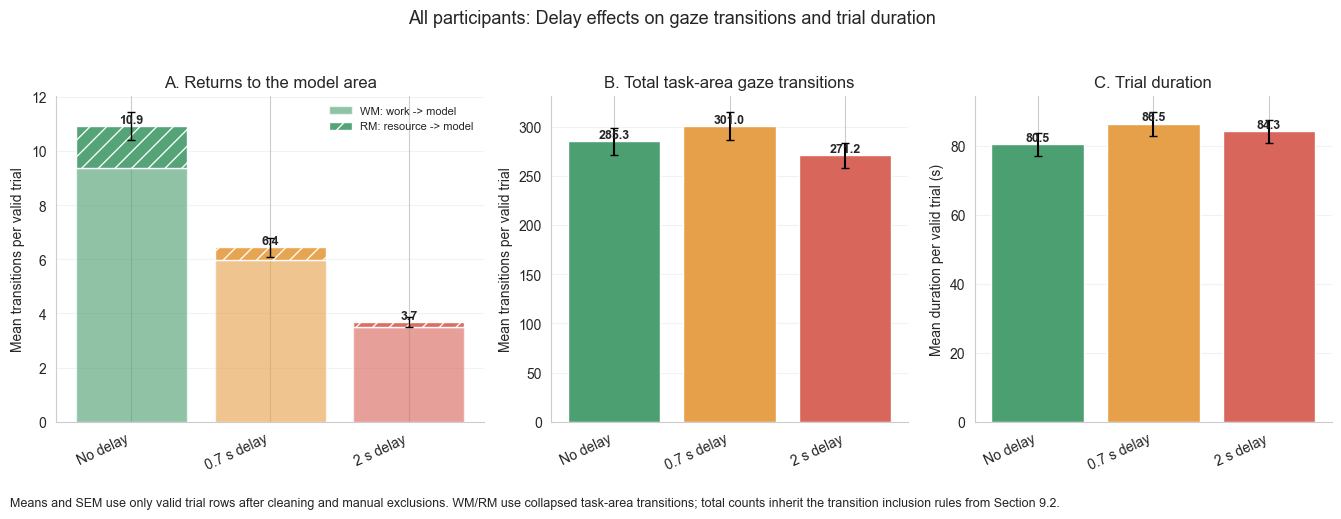

array([<Axes: title={'center': 'A. Returns to the model area'}, ylabel='Mean transitions per valid trial'>,
       <Axes: title={'center': 'B. Total task-area gaze transitions'}, ylabel='Mean transitions per valid trial'>,
       <Axes: title={'center': 'C. Trial duration'}, ylabel='Mean duration per valid trial (s)'>],
      dtype=object)

In [43]:
MELNIK_FIG5_CONDITION_COLORS = {
    1: "#4C9F70",  # clear green: no delay
    2: "#E6A04A",  # amber: short delay
    3: "#D8665B",  # muted red: long delay
}


def melnik_fig5_trial_tables_all(
    transition_trial_counts,
    trial_durations,
    group_cols=GROUP_COLS,
):
    """Create aligned valid-trial tables for Figure 5-style panels A, B, and C."""
    trial_keys = (
        transition_trial_counts[group_cols]
        .drop_duplicates()
        .sort_values(group_cols)
        .reset_index(drop=True)
    )

    model_return_counts = (
        transition_trial_counts[transition_trial_counts["saccade_type"].isin(["WM", "RM"])]
        .pivot_table(
            index=group_cols,
            columns="saccade_type",
            values="n_saccades",
            aggfunc="sum",
            fill_value=0,
        )
        .reset_index()
    )
    for col in ["WM", "RM"]:
        if col not in model_return_counts.columns:
            model_return_counts[col] = 0
    model_return_counts = trial_keys.merge(
        model_return_counts,
        on=group_cols,
        how="left",
        validate="one_to_one",
    ).fillna({"WM": 0, "RM": 0})
    model_return_counts["model_area_returns"] = model_return_counts["WM"] + model_return_counts["RM"]

    total_transition_counts = (
        transition_trial_counts.groupby(group_cols, dropna=False)["n_saccades"]
        .sum()
        .rename("total_task_area_transitions")
        .reset_index()
    )
    total_transition_counts = trial_keys.merge(
        total_transition_counts,
        on=group_cols,
        how="left",
        validate="one_to_one",
    ).fillna({"total_task_area_transitions": 0})

    aligned_durations = trial_keys.merge(
        trial_durations,
        on=group_cols,
        how="left",
        validate="one_to_one",
        indicator=True,
    )
    missing_duration = aligned_durations["_merge"].ne("both") | aligned_durations["trial_duration_s"].isna()
    if missing_duration.any():
        missing_keys = aligned_durations.loc[missing_duration, group_cols]
        raise ValueError(f"Missing trial duration for {len(missing_keys)} valid transition trial(s).")
    aligned_durations = aligned_durations.drop(columns="_merge")

    expected_n_trials = len(trial_keys)
    actual_sizes = {
        "model returns": len(model_return_counts),
        "total transitions": len(total_transition_counts),
        "trial durations": len(aligned_durations),
    }
    if any(size != expected_n_trials for size in actual_sizes.values()):
        raise ValueError(f"Figure 5 trial-table mismatch: expected {expected_n_trials}, got {actual_sizes}")

    return model_return_counts, total_transition_counts, aligned_durations


def melnik_fig5_mean_sem_all(table, value_col):
    """Mean and SEM across the valid trial rows in each condition."""
    summary = (
        table.groupby("condition_number", dropna=False)
        .agg(
            mean=(value_col, "mean"),
            sem=(value_col, melnik_sem),
            n_trials=(value_col, "size"),
            n_participants=("participant_id", "nunique"),
        )
        .reset_index()
    )
    summary["condition_label"] = summary["condition_number"].map(MELNIK_CONDITION_LABELS)
    return summary


def melnik_fig5_component_summary_all(model_return_counts):
    """Mean WM/RM returns plus SEM and denominators for their total."""
    component = (
        model_return_counts.groupby("condition_number", dropna=False)[["WM", "RM", "model_area_returns"]]
        .mean()
        .reset_index()
    )
    total_summary = melnik_fig5_mean_sem_all(model_return_counts, "model_area_returns")[
        ["condition_number", "sem", "n_trials", "n_participants"]
    ]
    component = component.merge(total_summary, on="condition_number", how="left", validate="one_to_one")
    component["condition_label"] = component["condition_number"].map(MELNIK_CONDITION_LABELS)
    return component


def plot_melnik_figure5_style_all(model_return_counts, total_transition_counts, trial_durations):
    """Plot the all-participant three-panel Melnik Figure 5-style summary."""
    condition_numbers = [
        cond for cond in MELNIK_CONDITION_LABELS
        if cond in set(model_return_counts["condition_number"])
    ]
    condition_labels = [MELNIK_CONDITION_LABELS[cond] for cond in condition_numbers]
    colors = [MELNIK_FIG5_CONDITION_COLORS[cond] for cond in condition_numbers]
    x = np.arange(len(condition_numbers))

    model_return_summary = melnik_fig5_component_summary_all(model_return_counts).set_index("condition_number")
    total_transition_summary = melnik_fig5_mean_sem_all(
        total_transition_counts, "total_task_area_transitions"
    ).set_index("condition_number")
    duration_summary = melnik_fig5_mean_sem_all(
        trial_durations, "trial_duration_s"
    ).set_index("condition_number")

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1.2, 1, 1]})
    fig.suptitle("All participants: Delay effects on gaze transitions and trial duration", y=1.04, fontsize=13)

    ax = axes[0]
    wm_means = model_return_summary.reindex(condition_numbers)["WM"].fillna(0).to_numpy(dtype=float)
    rm_means = model_return_summary.reindex(condition_numbers)["RM"].fillna(0).to_numpy(dtype=float)
    total_means = model_return_summary.reindex(condition_numbers)["model_area_returns"].fillna(0).to_numpy(dtype=float)
    total_sems = model_return_summary.reindex(condition_numbers)["sem"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, wm_means, color=colors, alpha=0.62, edgecolor="white", linewidth=1.0, label="WM: work -> model")
    ax.bar(x, rm_means, bottom=wm_means, color=colors, alpha=0.95, edgecolor="white", linewidth=1.0, hatch="//", label="RM: resource -> model")
    ax.errorbar(x, total_means, yerr=total_sems, fmt="none", ecolor="black", capsize=3, lw=1)
    for xpos, total in zip(x, total_means):
        ax.text(xpos, total, f"{total:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title("A. Returns to the model area")
    ax.set_ylabel("Mean transitions per valid trial")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels, rotation=25, ha="right")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    means = total_transition_summary.reindex(condition_numbers)["mean"].fillna(0).to_numpy(dtype=float)
    sems = total_transition_summary.reindex(condition_numbers)["sem"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, means, yerr=sems, capsize=3, color=colors, edgecolor="white", linewidth=1.0)
    for xpos, mean in zip(x, means):
        ax.text(xpos, mean, f"{mean:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title("B. Total task-area gaze transitions")
    ax.set_ylabel("Mean transitions per valid trial")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels, rotation=25, ha="right")

    ax = axes[2]
    means = duration_summary.reindex(condition_numbers)["mean"].fillna(0).to_numpy(dtype=float)
    sems = duration_summary.reindex(condition_numbers)["sem"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, means, yerr=sems, capsize=3, color=colors, edgecolor="white", linewidth=1.0)
    for xpos, mean in zip(x, means):
        ax.text(xpos, mean, f"{mean:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title("C. Trial duration")
    ax.set_ylabel("Mean duration per valid trial (s)")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels, rotation=25, ha="right")

    for ax in axes:
        ax.grid(axis="y", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_axisbelow(True)

    fig.text(
        0.01,
        -0.04,
        "Means and SEM use only valid trial rows after cleaning and manual exclusions. "
        "WM/RM use collapsed task-area transitions; total counts inherit the transition inclusion rules from Section 9.2.",
        ha="left",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()
    return axes


(
    all_participant_melnik_fig5_model_return_counts,
    all_participant_melnik_fig5_total_transition_counts,
    all_participant_melnik_fig5_trial_durations,
) = melnik_fig5_trial_tables_all(
    all_participant_melnik_transition_trial_counts,
    all_participant_trial_durations,
)

all_participant_melnik_fig5_model_return_summary = melnik_fig5_component_summary_all(
    all_participant_melnik_fig5_model_return_counts
)
all_participant_melnik_fig5_total_transition_summary = melnik_fig5_mean_sem_all(
    all_participant_melnik_fig5_total_transition_counts,
    "total_task_area_transitions",
)
all_participant_melnik_fig5_trial_duration_summary = melnik_fig5_mean_sem_all(
    all_participant_melnik_fig5_trial_durations,
    "trial_duration_s",
)

print("Panel A: model-area returns per valid trial")
display(all_participant_melnik_fig5_model_return_summary.round(2))
print("Panel B: total task-area transitions per valid trial")
display(all_participant_melnik_fig5_total_transition_summary.round(2))
print("Panel C: valid-trial duration in seconds")
display(all_participant_melnik_fig5_trial_duration_summary.round(2))

plot_melnik_figure5_style_all(
    all_participant_melnik_fig5_model_return_counts,
    all_participant_melnik_fig5_total_transition_counts,
    all_participant_melnik_fig5_trial_durations,
)


## 9.4 Mean Model-Area Fixation Duration Across Participants

This section applies the fixation-duration analysis validated in `lego_practice_Azad.ipynb` to every participant. It retains fixation events with fixation-level `gaze_space == "model_area"`. This includes template bricks, the model plate/front, and the model desk. `model_visibility_state` is not used in this analysis.

Duration is audited from the fixation start/end `time_ms` values. Events shorter than 50 ms or containing a gap longer than five nominal sample periods are excluded. The RAM-friendly streaming pass keeps only one compact row per valid trial after cleaning and manual exclusions.

To prevent participants with more valid trials from receiving more weight, the analysis calculates trial means first and then one mean per participant and condition. Bars show the mean of those participant means, error bars show SEM across participants, and dots show individual participant means.


All-participant valid model-area fixation-duration summary


,condition_number,mean_fixation_duration_ms,sem_fixation_duration_ms,n_participants,n_trials,n_model_area_fixations,condition_label
0,1,233.62,6.24,49,289,12002,No delay
1,2,344.82,13.12,49,290,16645,0.7 s delay
2,3,456.70,23.39,49,284,14790,2 s delay


Participant-level means used in the comparison


,participant_id,condition_number,participant_mean_fixation_duration_ms,n_trials,n_model_area_fixations
0,001,1,181.06,6,221
1,001,2,277.84,6,562
2,001,3,425.18,6,431
3,002,1,309.18,6,223
4,002,2,428.28,6,399
...,...,...,...,...,...
142,050,2,403.70,6,488
143,050,3,550.35,5,422
144,051,1,200.53,6,150
145,051,2,388.48,6,225


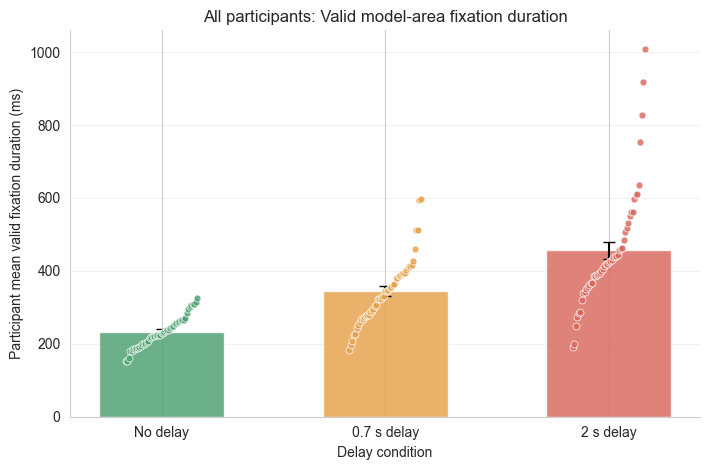

<Axes: title={'center': 'All participants: Valid model-area fixation duration'}, xlabel='Delay condition', ylabel='Participant mean valid fixation duration (ms)'>

In [44]:
def summarize_model_area_fixation_duration_all(trial_summary):
    """Create participant-balanced condition summaries from valid trial means."""
    participant_summary = (
        trial_summary.groupby(["participant_id", "condition_number"], dropna=False)
        .agg(
            participant_mean_fixation_duration_ms=("mean_fixation_duration_ms", "mean"),
            n_trials=("trial_number", "size"),
            n_model_area_fixations=("n_model_area_fixations", "sum"),
        )
        .reset_index()
    )

    condition_summary = (
        participant_summary.groupby("condition_number", dropna=False)
        .agg(
            mean_fixation_duration_ms=("participant_mean_fixation_duration_ms", "mean"),
            sem_fixation_duration_ms=("participant_mean_fixation_duration_ms", melnik_sem),
            n_participants=("participant_id", "nunique"),
            n_trials=("n_trials", "sum"),
            n_model_area_fixations=("n_model_area_fixations", "sum"),
        )
        .reset_index()
    )
    condition_summary["condition_label"] = condition_summary["condition_number"].map(
        MELNIK_CONDITION_LABELS
    )
    return participant_summary, condition_summary


def plot_model_area_fixation_duration_all(participant_summary, condition_summary):
    """Plot participant-balanced condition means and SEM with participant points."""
    condition_numbers = [
        cond for cond in MELNIK_CONDITION_LABELS
        if cond in set(condition_summary["condition_number"])
    ]
    x = np.arange(len(condition_numbers))
    labels = [MELNIK_CONDITION_LABELS[cond] for cond in condition_numbers]
    colors = [MELNIK_FIG5_CONDITION_COLORS[cond] for cond in condition_numbers]

    indexed = condition_summary.set_index("condition_number").reindex(condition_numbers)
    means = indexed["mean_fixation_duration_ms"].to_numpy(dtype=float)
    sems = indexed["sem_fixation_duration_ms"].fillna(0).to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.bar(
        x,
        means,
        width=0.56,
        yerr=sems,
        capsize=4,
        color=colors,
        alpha=0.82,
        edgecolor="white",
        linewidth=1.0,
        zorder=2,
    )

    for xpos, cond, color in zip(x, condition_numbers, colors):
        values = participant_summary.loc[
            participant_summary["condition_number"].eq(cond),
            "participant_mean_fixation_duration_ms",
        ].sort_values().to_numpy(dtype=float)
        offsets = np.linspace(-0.16, 0.16, len(values)) if len(values) > 1 else np.zeros(len(values))
        ax.scatter(
            xpos + offsets,
            values,
            s=25,
            color=color,
            edgecolor="white",
            linewidth=0.6,
            alpha=0.82,
            zorder=3,
        )

    ax.set_title("All participants: Valid model-area fixation duration")
    ax.set_xlabel("Delay condition")
    ax.set_ylabel("Participant mean valid fixation duration (ms)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()
    return ax


(
    all_participant_model_area_fixation_participant_summary,
    all_participant_model_area_fixation_condition_summary,
) = summarize_model_area_fixation_duration_all(
    all_participant_model_area_fixation_trial_summary
)

print("All-participant valid model-area fixation-duration summary")
display(all_participant_model_area_fixation_condition_summary.round(2))
print("Participant-level means used in the comparison")
display(all_participant_model_area_fixation_participant_summary.round(2))

plot_model_area_fixation_duration_all(
    all_participant_model_area_fixation_participant_summary,
    all_participant_model_area_fixation_condition_summary,
)


NameError: name 'df' is not defined

## 9.5 Plot Helpers

The helper below makes consistent Yes/No bar charts and annotates both percentage and count.



In [ ]:
def yes_no_counts(table, match_col):
    if table.empty or match_col not in table.columns:
        return pd.Series({"No": 0, "Yes": 0})

    return (
        table[match_col]
        .astype("boolean")
        .map({False: "No", True: "Yes"})
        .value_counts()
        .reindex(["No", "Yes"], fill_value=0)
    )


def plot_yes_no_bar(table, match_col, title, ylabel):
    counts = yes_no_counts(table, match_col)
    x = np.arange(len(counts))
    bar_width = 0.34

    fig, ax = plt.subplots(figsize=(4.8, 3.6))
    bars = ax.bar(
        x,
        counts.values,
        width=bar_width,
        color=["#6F8FB6", "#2E8B57"],
        edgecolor="white",
        linewidth=1.2,
    )

    ax.set_title(title, pad=10)
    ax.set_xlabel("Match")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(counts.index)
    ax.set_xlim(-0.6, len(counts) - 0.4)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    total = counts.sum()
    y_max = max(counts.max() * 1.24, 1)
    for bar, count in zip(bars, counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.025,
            f"{pct:.1f}%\n(n={int(count)})",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

    ax.set_ylim(0, y_max)
    plt.tight_layout()
    plt.show()
    return counts, ax


## 9.6 Previous Model-Brick Fixation Match Plots

These plots answer whether the grabbed brick ID matched the previous model-area template-brick fixation target.

- exact-last: grabbed brick matches the single most recent previous model-brick fixation
- last-five: grabbed brick appears anywhere in the last five previous model-brick fixations



In [ ]:
exact_last_counts, _ = plot_yes_no_bar(
    all_participant_previous_fixation_matches,
    "match_exact_last_fixation",
    "All participants: match with exact last model-brick fixation",
    "Number of resource-side brick grabs",
)

last_five_counts, _ = plot_yes_no_bar(
    all_participant_previous_fixation_matches,
    "match_last_five_fixations",
    "Match within last 5 model-brick fixations over participants",
    "Number of resource-side brick grabs",
)

previous_fixation_summary = pd.DataFrame({
    "match_rule": ["exact_last", "last_five"],
    "n_no": [exact_last_counts["No"], last_five_counts["No"]],
    "n_yes": [exact_last_counts["Yes"], last_five_counts["Yes"]],
})
previous_fixation_summary["n_total"] = previous_fixation_summary["n_no"] + previous_fixation_summary["n_yes"]
previous_fixation_summary["pct_yes"] = 100 * previous_fixation_summary["n_yes"] / previous_fixation_summary["n_total"]
display(previous_fixation_summary)


## 9.7 One-Hand Match Plots

One-hand decisions are resource-side brick grabs that are not paired into a dual-grab. The model frame is the most recent continuous block of model-area template-brick fixations before the grab.

The ranking is based on summed fixation duration, not sample count.



In [ ]:
all_participant_one_hand_decisions = all_participant_grab_decisions[
    all_participant_grab_decisions["condition_type"].eq("one_hand")
].copy()

one_hand_top1_counts, _ = plot_yes_no_bar(
    all_participant_one_hand_decisions,
    "match_top1_model_frame_brick",
    "All participants: one-hand match with top 1 previous model-frame brick",
    "Number of one-hand decisions",
)

one_hand_top2_counts, _ = plot_yes_no_bar(
    all_participant_one_hand_decisions,
    "match_top2_model_frame_bricks",
    "All participants: one-hand match within top 2 previous model-frame bricks",
    "Number of one-hand decisions",
)

one_hand_summary = pd.DataFrame({
    "match_rule": ["top_1_duration", "top_2_duration"],
    "n_no": [one_hand_top1_counts["No"], one_hand_top2_counts["No"]],
    "n_yes": [one_hand_top1_counts["Yes"], one_hand_top2_counts["Yes"]],
})
one_hand_summary["n_total"] = one_hand_summary["n_no"] + one_hand_summary["n_yes"]
one_hand_summary["pct_yes"] = 100 * one_hand_summary["n_yes"] / one_hand_summary["n_total"]
display(one_hand_summary)


## 9.8 Dual-Grab Match Plot

Dual-grab decisions are adjacent opposite-hand grabs before the participant returns gaze to a model-area template brick. A match is recorded when both grabbed brick IDs appear in the top four duration-ranked bricks from the previous model frame.



In [ ]:
all_participant_dual_grab_decisions = all_participant_grab_decisions[
    all_participant_grab_decisions["condition_type"].eq("dual_grab")
].copy()

dual_top4_counts, _ = plot_yes_no_bar(
    all_participant_dual_grab_decisions,
    "match_dual_top4_model_frame_bricks",
    "All participants: dual-grab match within top 4 previous model-frame bricks",
    "Number of dual-grab pairs",
)

dual_grab_summary = pd.DataFrame({
    "match_rule": ["both_bricks_in_top_4_duration"],
    "n_no": [dual_top4_counts["No"]],
    "n_yes": [dual_top4_counts["Yes"]],
})
dual_grab_summary["n_total"] = dual_grab_summary["n_no"] + dual_grab_summary["n_yes"]
dual_grab_summary["pct_yes"] = 100 * dual_grab_summary["n_yes"] / dual_grab_summary["n_total"]
display(dual_grab_summary)


## 9.9 Combined Match Plots

The combined rule uses the current final logic:

- one-hand: grabbed brick appears in the top 2 duration-ranked previous model-frame bricks
- dual-grab: both grabbed bricks appear in the top 5 duration-ranked previous model-frame bricks

Two summaries are shown:

- pooled event-level rate: every grab decision has equal weight
- mean participant-level rate: every participant has equal weight



In [ ]:
combined_counts, _ = plot_yes_no_bar(
    all_participant_grab_decisions,
    "match_combined_rule",
    "Combined grab match rate over participants",
    "Number of grab decisions",
)

combined_condition_summary = (
    all_participant_grab_decisions
    .groupby(["condition_type", "match_combined_rule"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)

display(combined_condition_summary)

participant_match_summary = (
    all_participant_grab_decisions
    .groupby("participant_id", dropna=False)
    .agg(
        n_decisions=("match_combined_rule", "size"),
        n_matches=("match_combined_rule", "sum"),
        n_one_hand=("condition_type", lambda s: s.eq("one_hand").sum()),
        n_dual_pairs=("condition_type", lambda s: s.eq("dual_grab").sum()),
    )
    .reset_index()
)
participant_match_summary["pct_match"] = 100 * participant_match_summary["n_matches"] / participant_match_summary["n_decisions"]

display(participant_match_summary)

pooled_match_rate = 100 * combined_counts["Yes"] / combined_counts.sum() if combined_counts.sum() else 0
mean_participant_match_rate = participant_match_summary["pct_match"].mean()

print(f"Pooled event-level match rate: {pooled_match_rate:.1f}%")
print(f"Mean participant-level match rate: {mean_participant_match_rate:.1f}%")

participant_average_counts = pd.Series({
    "No": 100 - mean_participant_match_rate,
    "Yes": mean_participant_match_rate,
})

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(participant_average_counts.index, participant_average_counts.values, width=0.45, color=["#6F8FB6", "#2E8B57"])
ax.set_title("All participants: mean participant-level combined match rate")
ax.set_xlabel("Match")
ax.set_ylabel("Mean participant percentage")
ax.set_ylim(0, 100)

for bar, pct in zip(bars, participant_average_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


## 9.10 Combined Match Within Last 5 Previous Model-Brick Fixations

This is the same one-hand/dual-grab decision grouping as the combined plot above, but the match rule changes:

- one-hand: grabbed brick appears in the last five previous model-area `temp_` brick fixations
- dual-grab: both grabbed bricks appear in the last five previous model-area `temp_` brick fixations before the first grab

This does not use fixation-duration ranking.



In [ ]:
# Combined match-rate using the last five previous model-brick fixations.
# This reuses the existing one-hand/dual-grab grouping from all_participant_grab_decisions.


def make_previous_last5_lookup(previous_matches):
    """Map each resource-side brick grab to its last-five previous model-brick fixation IDs."""
    lookup = {}

    for _, row in previous_matches.iterrows():
        key = (
            str(row["participant_id"]).zfill(3),
            row["condition_number"],
            row["trial_number"],
            row["grab_hand"],
            row["grab_start_ms"],
            str(row["grabbed_brick_id"]),
        )
        lookup[key] = [str(brick_id) for brick_id in row["previous_model_fixation_brick_ids"]]

    return lookup


def add_combined_last5_match(decisions, previous_matches):
    """Add combined match labels based on last-five previous model-brick fixations."""
    previous_lookup = make_previous_last5_lookup(previous_matches)
    out = decisions.copy()

    last5_lists = []
    match_values = []

    for _, row in out.iterrows():
        grabbed_ids = [str(brick_id) for brick_id in row["grabbed_brick_ids"]]
        first_grabbed_id = grabbed_ids[0] if grabbed_ids else pd.NA

        key = (
            str(row["participant_id"]).zfill(3),
            row["condition_number"],
            row["trial_number"],
            row["first_grab_hand"],
            row["first_grab_start_ms"],
            str(first_grabbed_id),
        )

        last5_ids = previous_lookup.get(key, [])
        last5_lists.append(last5_ids)
        match_values.append(all(brick_id in last5_ids for brick_id in grabbed_ids))

    out["last5_model_fixation_brick_ids"] = last5_lists
    out["match_combined_last5_model_fixations"] = match_values
    return out


all_participant_combined_last5_results = add_combined_last5_match(
    all_participant_grab_decisions,
    all_participant_previous_fixation_matches,
)

combined_last5_counts, _ = plot_yes_no_bar(
    all_participant_combined_last5_results,
    "match_combined_last5_model_fixations",
    "All participants: combined match within last 5 model-brick fixations",
    "Number of grab decisions",
)

combined_last5_condition_summary = (
    all_participant_combined_last5_results
    .groupby(["condition_type", "match_combined_last5_model_fixations"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)

display(combined_last5_condition_summary)

combined_last5_participant_summary = (
    all_participant_combined_last5_results
    .groupby("participant_id", dropna=False)
    .agg(
        n_decisions=("match_combined_last5_model_fixations", "size"),
        n_matches=("match_combined_last5_model_fixations", "sum"),
        n_one_hand=("condition_type", lambda s: s.eq("one_hand").sum()),
        n_dual_pairs=("condition_type", lambda s: s.eq("dual_grab").sum()),
    )
    .reset_index()
)
combined_last5_participant_summary["pct_match"] = (
    100 * combined_last5_participant_summary["n_matches"] / combined_last5_participant_summary["n_decisions"]
)

display(combined_last5_participant_summary)

pooled_last5_match_rate = (
    100 * combined_last5_counts["Yes"] / combined_last5_counts.sum()
    if combined_last5_counts.sum()
    else 0
)
mean_participant_last5_match_rate = combined_last5_participant_summary["pct_match"].mean()

print(f"Pooled event-level last-five match rate: {pooled_last5_match_rate:.1f}%")
print(f"Mean participant-level last-five match rate: {mean_participant_last5_match_rate:.1f}%")


# 10. Final Objects

Main all-participant objects produced by this notebook:

- `all_participant_previous_fixation_matches`: exact-last and last-five previous model-brick fixation checks
- `all_participant_grab_decisions`: one-hand, dual-grab, and combined match decisions
- `all_participant_coverage_report`: participant-level coverage and row-count diagnostics
- `participant_match_summary`: participant-level duration-ranked combined match rates
- `all_participant_combined_last5_results`: combined match decisions using the last five previous model-brick fixations
- `combined_last5_participant_summary`: participant-level last-five combined match rates
- `all_participant_melnik_transition_trial_counts`: valid-trial transition counts for Melnik-style M/W/R gaze transitions
- `all_participant_melnik_transition_summary`: all-participant mean +/- SEM transition counts by delay condition
- `all_participant_trial_durations`: compact valid-trial duration table retained during participant streaming
- `all_participant_melnik_fig5_model_return_summary`: Figure 5-style WM/RM model-return summary
- `all_participant_melnik_fig5_total_transition_summary`: Figure 5-style total transition summary
- `all_participant_melnik_fig5_trial_duration_summary`: Figure 5-style valid-trial duration summary
- `all_participant_model_area_fixation_trial_summary`: compact valid-trial model-area fixation-duration means
- `all_participant_model_area_fixation_participant_summary`: participant-level condition means used in Section 9.4
- `all_participant_model_area_fixation_condition_summary`: participant-balanced condition mean and SEM
